<a href="https://colab.research.google.com/github/ThanhThaoBT/PTDL2025/blob/main/MohinhPhanCum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự Án Phân Tích Chuyên Sâu Bất Động Sản: Áp Dụng Học Máy để Dự Đoán Giá và Phân Cụm Thị Trường

In [ ]:
# Thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Scikit-learn cho mô hình hóa và tiền xử lý
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Mô hình Hồi quy (Regression Models)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Mô hình Phân cụm (Clustering Models)
from sklearn.cluster import KMeans

# Đánh giá Mô hình (Metrics)
from sklearn.metrics import mean_absolute_error, r2_score, silhouette_score, mean_squared_error

# Cấu hình để hiển thị biểu đồ tốt hơn
%matplotlib inline

In [ ]:
# Thiết lập tùy chọn hiển thị
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
np.random.seed(42) # Đặt seed để đảm bảo kết quả có thể tái lập

# Tải dữ liệu từ file đã cung cấp
df = pd.read_csv("cleaned_data.csv")

# Kiểm tra nhanh kích thước và cấu trúc dữ liệu
print(f"Kích thước dữ liệu ban đầu: {df.shape}")
print("\nThông tin 5 dòng đầu:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print("\nThông tin cột và kiểu dữ liệu:")
df.info()

Kích thước dữ liệu ban đầu: (9072, 11)

Thông tin 5 dòng đầu:
| bedrooms   | date       | bathrooms   | area   | legal_status   | title                                                                                              | price    | city            | link                                                                                                                    | district   | description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## Phần 2: Tiền Xử Lý & Kỹ Thuật Đặc Trưng (Advanced Preprocessing)

### 2.1. Lựa chọn Đặc Trưng và Làm sạch Logic (Feature Selection & Logical Cleaning)

In [ ]:
# 1. Chọn các cột có ý nghĩa cho việc dự đoán
# Loại bỏ các cột văn bản dài hoặc không liên quan trực tiếp đến mô hình số học
selected_cols = ['area', 'bedrooms', 'bathrooms', 'district', 'legal_status', 'price']
df_clean = df[selected_cols].copy()

# 2. Làm sạch Logic (Logical Cleaning)
# Loại bỏ các căn nhà có diện tích <= 0 hoặc giá <= 0 (nếu có)
df_clean = df_clean[(df_clean['area'] >=10) & (df_clean['price'] >= 100_000_000)]

# Loại bỏ các căn nhà có số phòng ngủ = 0 (trừ khi là đất nền, nhưng ở đây ta tập trung vào nhà)
df_clean = df_clean[df_clean['bedrooms'] >= 0]

print(f"Kích thước sau khi làm sạch logic: {df_clean.shape}")

Kích thước sau khi làm sạch logic: (9072, 6)


### 2.2. Xử lý Dữ Liệu Ngoại Lai Chuyên Sâu (Advanced Outlier Removal)

Kích thước sau khi loại bỏ Outliers: (7438, 6)


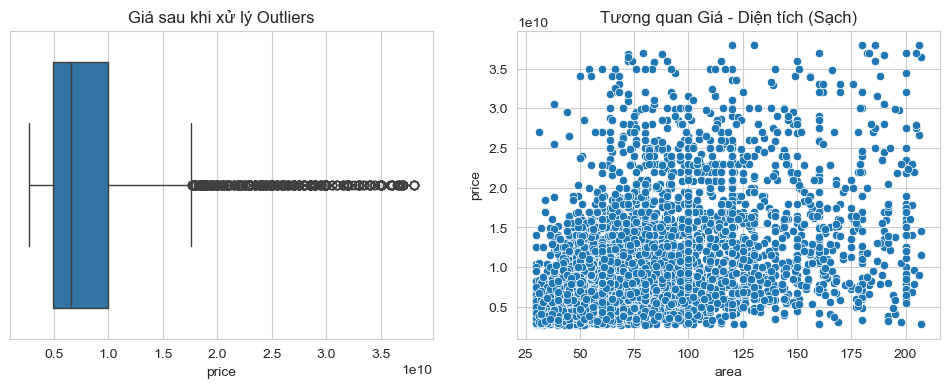

In [ ]:
def remove_outliers_iqr(data, column, lower_quantile=0.05, upper_quantile=0.95):
    """
    Hàm loại bỏ ngoại lai sử dụng phân vị (Quantile).
    Ta chỉ giữ lại dữ liệu nằm trong khoảng 5% đến 95% để loại bỏ các nhà siêu rẻ hoặc siêu đắt (biệt thự triệu đô).
    """
    lower_bound = data[column].quantile(lower_quantile)
    upper_bound = data[column].quantile(upper_quantile)

    # Lọc dữ liệu
    data_filtered = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data_filtered

# Áp dụng cho Giá và Diện tích
df_clean = remove_outliers_iqr(df_clean, 'price')
df_clean = remove_outliers_iqr(df_clean, 'area')

print(f"Kích thước sau khi loại bỏ Outliers: {df_clean.shape}")

# Kiểm tra lại phân phối
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean['price'])
plt.title('Giá sau khi xử lý Outliers')

plt.subplot(1, 2, 2)
sns.scatterplot(x='area', y='price', data=df_clean)
plt.title('Tương quan Giá - Diện tích (Sạch)')
plt.show()

### 2.3. Feature Engineering (Tạo biến đặc trưng mới)

In [ ]:
# 1. Tổng số phòng chức năng
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']

# 2. Tỷ lệ phòng tắm trên phòng ngủ (Nhà cao cấp thường có tỷ lệ này cao hơn)
df_clean['bath_per_bed'] = df_clean['bathrooms'] / df_clean['bedrooms']

# 3. Biến đổi Log cho Giá (Log Transformation)
# Giúp Linear Regression hoạt động tốt hơn vì phân phối giá thường lệch phải
df_clean['price_log'] = np.log1p(df_clean['price'])

# Kiểm tra dữ liệu mới
df_clean.head()

,area,bedrooms,bathrooms,district,legal_status,price,total_rooms,bath_per_bed,price_log
0,68.0,3,3,Bình Tân,Sổ đỏ/ Sổ hồng,6.700000e+09,6,1.000000,22.625373
1,80.0,6,5,Quận 7,Sổ đỏ/ Sổ hồng,1.680000e+10,11,0.833333,23.544645
2,56.0,4,3,Quận 12,Sổ đỏ/ Sổ hồng,5.700000e+09,7,0.750000,22.463732
4,160.0,4,3,Quận 7,Sổ đỏ/ Sổ hồng,1.500000e+10,7,0.750000,23.431316
5,115.0,9,3,Quận 5,Sổ đỏ/ Sổ hồng,1.990000e+10,12,0.333333,23.713986


### 2.4. Chia tập Train/Test (Data Splitting)

In [ ]:
# Tách biến độc lập (X) và biến phụ thuộc (y)
# Lưu ý: Ta sẽ dùng 'price_log' để huấn luyện mô hình dự đoán (tốt cho toán học),
# nhưng khi báo cáo kết quả ta sẽ chuyển ngược lại về giá thực.
X = df_clean.drop(['price', 'price_log'], axis=1)
y = df_clean['price_log'] # Target là Log Price

# Chia tập dữ liệu: 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước Train: {X_train.shape}")
print(f"Kích thước Test: {X_test.shape}")

Kích thước Train: (5950, 7)
Kích thước Test: (1488, 7)


### 2.5. Xây Dựng Pipeline Tiền Xử Lý (Professional Pipeline)

In [ ]:
# Định nghĩa danh sách các cột
numeric_features = ['area', 'bedrooms', 'bathrooms', 'total_rooms', 'bath_per_bed']
categorical_features = ['district', 'legal_status']

# 1. Pipeline xử lý biến SỐ
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Điền giá trị thiếu bằng trung vị
    ('scaler', StandardScaler())                   # Chuẩn hóa về mean=0, std=1 (BẮT BUỘC cho K-Means)
])

# 2. Pipeline xử lý biến PHÂN LOẠI
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False để dễ xem dạng bảng
])

# 3. Tổng hợp Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Bỏ qua các cột không được liệt kê
)

# 4. Áp dụng Preprocessor
# Fit trên tập Train
X_train_processed = preprocessor.fit_transform(X_train)
# Transform trên tập Test (không fit lại)
X_test_processed = preprocessor.transform(X_test)

# Lấy tên các cột sau khi One-Hot Encoding để tiện theo dõi sau này (quan trọng cho Feature Importance)
# Bước này hơi kỹ thuật một chút để lấy lại tên cột
ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)

print("Đã hoàn tất tiền xử lý!")
print(f"Số lượng đặc trưng (features) sau khi xử lý: {X_train_processed.shape[1]}")

Đã hoàn tất tiền xử lý!
Số lượng đặc trưng (features) sau khi xử lý: 31


## Phần 3: Xây dựng & Đánh giá Mô hình Dự đoán Giá (Supervised Learning)

### 3.1. Thiết lập Hàm Đánh giá Chuẩn (Evaluation Function)

In [ ]:
# Hàm đánh giá chung cho tất cả mô hình
def evaluate_model(model, X_test, y_test, model_name):
    # 1. Dự đoán trên tập Test
    y_pred_log = model.predict(X_test)

    # 2. Chuyển đổi ngược từ Log Price -> Real Price (VND)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    # 3. Tính toán các chỉ số
    # MAE: Sai số tuyệt đối trung bình (Dễ hiểu nhất: "Lệch bao nhiêu tiền?")
    mae = mean_absolute_error(y_test_real, y_pred_real)

    # RMSE: Căn bậc hai của sai số bình phương trung bình (Phạt nặng các sai số lớn)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

    # R2 Score: Độ phù hợp của mô hình (Càng gần 1 càng tốt)
    r2 = r2_score(y_test_real, y_pred_real)

    print(f"--- {model_name} ---")
    print(f"R2 Score (Độ chính xác): {r2:.4f}")
    print(f"MAE (Sai số trung bình): {mae:,.0f} VND")
    print(f"RMSE (Sai số toàn phương): {rmse:,.0f} VND")
    print("-" * 30)

    return {'Model': model_name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

# Tạo danh sách để lưu kết quả so sánh
results_list = []

### 3.2. Mô hình 1: Hồi Quy Tuyến Tính (Linear Regression)

In [ ]:
# Khởi tạo và huấn luyện
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Đánh giá
results_list.append(evaluate_model(lr_model, X_test_processed, y_test, "Linear Regression"))

--- Linear Regression ---
R2 Score (Độ chính xác): 0.3858
MAE (Sai số trung bình): 2,646,054,933 VND
RMSE (Sai số toàn phương): 4,512,526,270 VND
------------------------------


### 3.3. Mô hình 2: Cây Quyết Định (Decision Tree Regressor)

In [ ]:
# Khởi tạo (giới hạn độ sâu max_depth=10 để tránh overfitting)
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_processed, y_train)

# Đánh giá
results_list.append(evaluate_model(dt_model, X_test_processed, y_test, "Decision Tree"))

--- Decision Tree ---
R2 Score (Độ chính xác): 0.4079
MAE (Sai số trung bình): 2,637,666,464 VND
RMSE (Sai số toàn phương): 4,430,779,452 VND
------------------------------


### 3.4. Mô hình 3: Rừng Ngẫu Nhiên (Random Forest Regressor)

In [ ]:
# Khởi tạo (100 cây, sử dụng tất cả lõi CPU với n_jobs=-1)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# Đánh giá
results_list.append(evaluate_model(rf_model, X_test_processed, y_test, "Random Forest"))

--- Random Forest ---
R2 Score (Độ chính xác): 0.5916
MAE (Sai số trung bình): 2,244,792,220 VND
RMSE (Sai số toàn phương): 3,679,810,002 VND
------------------------------


### 3.5. Mô hình 4: Gradient Boosting (Mô hình Nâng cao)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Khởi tạo
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_processed, y_train)

# Đánh giá
results_list.append(evaluate_model(gb_model, X_test_processed, y_test, "Gradient Boosting"))

--- Gradient Boosting ---
R2 Score (Độ chính xác): 0.5713
MAE (Sai số trung bình): 2,319,247,005 VND
RMSE (Sai số toàn phương): 3,769,944,568 VND
------------------------------


### 3.6. So sánh và Tổng hợp Kết quả

                         R2           MAE          RMSE
Model                                                  
Random Forest      0.591598  2.244792e+09  3.679810e+09
Gradient Boosting  0.571346  2.319247e+09  3.769945e+09
Decision Tree      0.407897  2.637666e+09  4.430779e+09
Linear Regression  0.385847  2.646055e+09  4.512526e+09


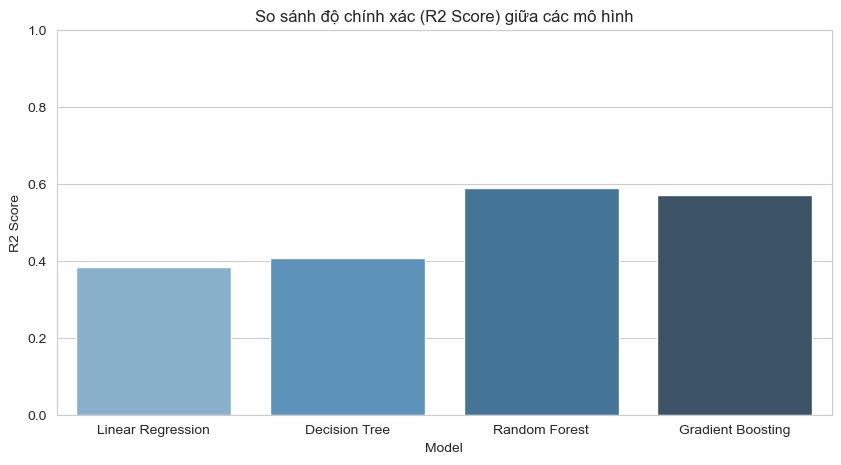

In [ ]:
# Tạo DataFrame so sánh
comparison_df = pd.DataFrame(results_list).set_index('Model')

# Sắp xếp theo R2 giảm dần (Cao nhất lên đầu)
print(comparison_df.sort_values(by='R2', ascending=False))

# Vẽ biểu đồ so sánh R2 Score
plt.figure(figsize=(10, 5))

sns.barplot(
    x=comparison_df.index,
    y=comparison_df['R2'],
    palette='Blues_d',
    hue=comparison_df.index, # <--- Đã thêm: Gán hue bằng trục x
    legend=False             # <--- Đã thêm: Tắt chú thích thừa
)

plt.title('So sánh độ chính xác (R2 Score) giữa các mô hình')
plt.ylim(0, 1) # R2 nằm trong khoảng 0-1
plt.ylabel('R2 Score')
plt.show()

### 3.7. Phân tích Các Yếu Tố Ảnh Hưởng (Feature Importance)

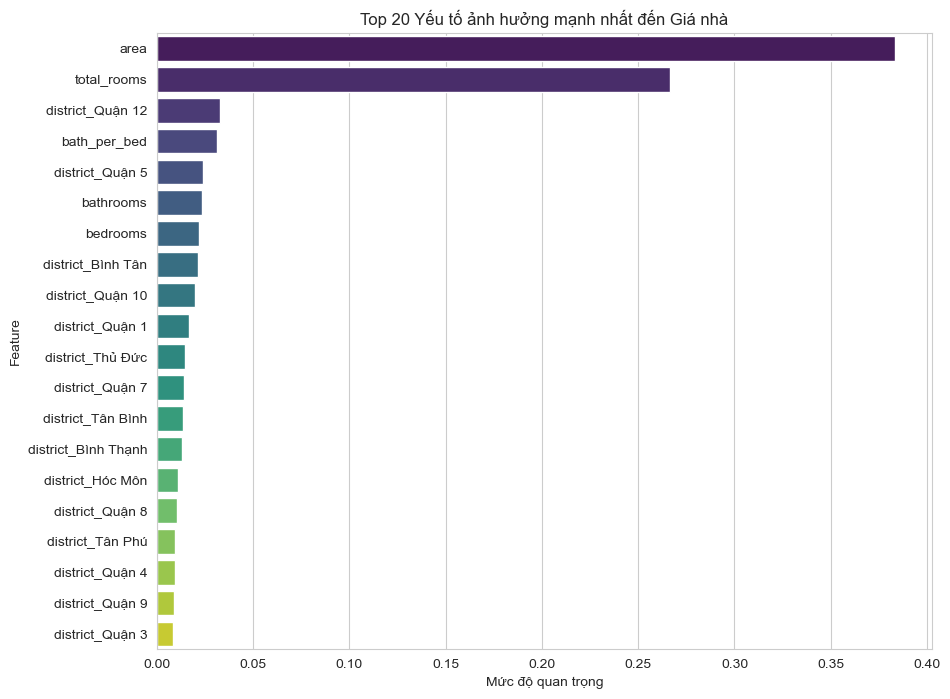

In [ ]:
# Lấy mô hình tốt nhất (ví dụ Random Forest)
best_model = rf_model

# Lấy giá trị tầm quan trọng
importances = best_model.feature_importances_

# Lấy tên cột từ danh sách đã lưu ở Phần 2
# (Biến all_feature_names chúng ta đã tạo ở cuối Phần 2)
feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

# Sắp xếp và lấy Top 20 yếu tố quan trọng nhất
top_20_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_20_features,
    palette='viridis',
    hue='Feature', # <--- Đã thêm: Gán hue bằng tên biến ở trục y
    legend=False   # <--- Đã thêm: Tắt chú thích thừa
)

plt.title('Top 20 Yếu tố ảnh hưởng mạnh nhất đến Giá nhà')
plt.xlabel('Mức độ quan trọng')
plt.show()

### 3.8. Trực quan hóa: Giá Dự đoán vs. Giá Thực tế

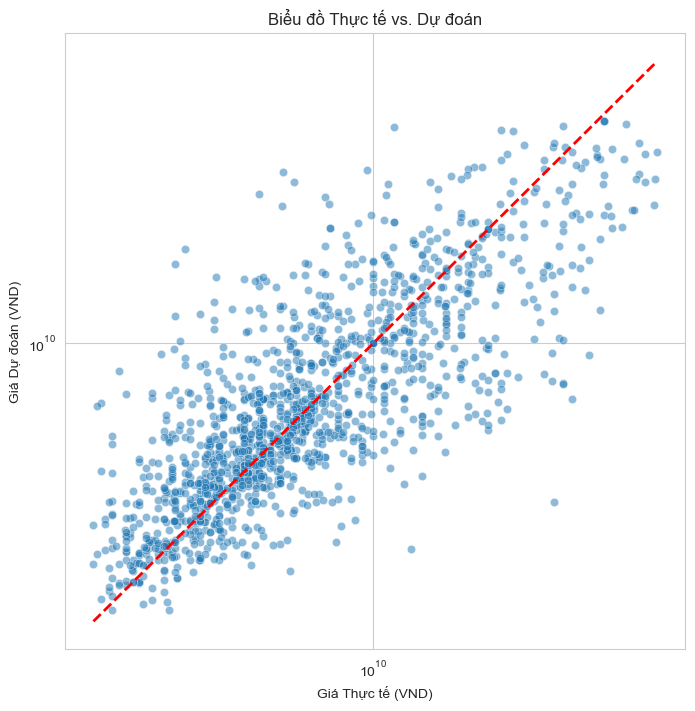

In [ ]:
# Dự đoán lại với mô hình tốt nhất
y_pred_log = best_model.predict(X_test_processed)
y_pred_final = np.expm1(y_pred_log)
y_test_final = np.expm1(y_test)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_final, y=y_pred_final, alpha=0.5)

# Vẽ đường chéo tham chiếu (Hoàn hảo)
max_val = max(y_test_final.max(), y_pred_final.max())
min_val = min(y_test_final.min(), y_pred_final.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Biểu đồ Thực tế vs. Dự đoán')
plt.xlabel('Giá Thực tế (VND)')
plt.ylabel('Giá Dự đoán (VND)')

# Dùng thang đo Log cho trục để dễ nhìn các giá trị lớn
plt.xscale('log')
plt.yscale('log')
plt.show()

## Phần 4: Phân Cụm Dữ Liệu (Unsupervised Learning).

### 4.1. Chuẩn Bị Dữ Liệu Cho Phân Cụm

In [ ]:
# 1. Chọn đặc trưng để phân cụm
# Ta chọn: Diện tích, Số phòng ngủ, Số phòng tắm, và Giá (để phân nhóm theo phân khúc tài chính)
cluster_cols = ['area', 'bedrooms', 'bathrooms', 'price']
X_cluster = df_clean[cluster_cols].copy()

# 2. Chuẩn hóa dữ liệu (Bước BẮT BUỘC với thuật toán tính khoảng cách)
# Vì 'giá' là hàng tỷ, 'số phòng' là hàng đơn vị -> Nếu không chuẩn hóa, 'giá' sẽ áp đảo hoàn toàn.
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Chuyển về DataFrame để dễ xử lý sau này
X_cluster_df = pd.DataFrame(X_cluster_scaled, columns=cluster_cols)

### 4.2. Tìm Số Cụm Tối Ưu ($k$): Phương Pháp Elbow

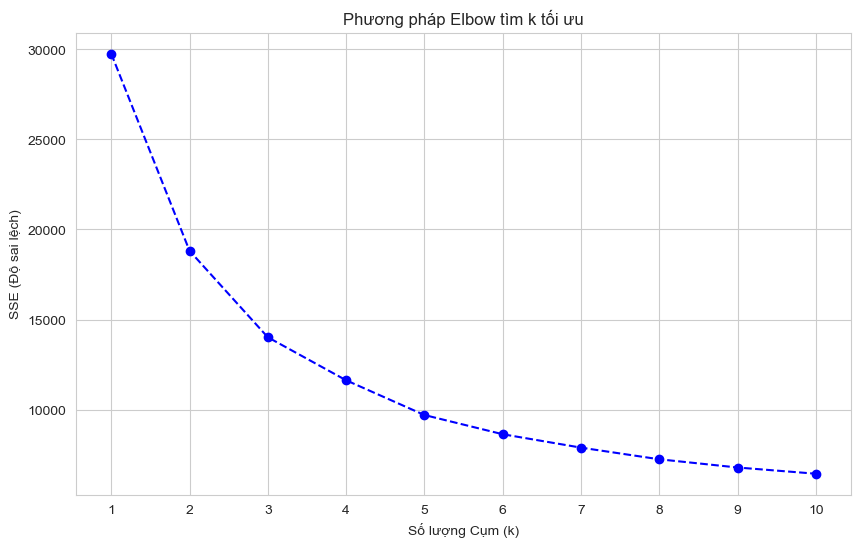

In [ ]:
sse = [] # Tổng bình phương sai số (Sum of Squared Errors)
list_k = range(1, 11)

for k in list_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    sse.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(list_k, sse, marker='o', linestyle='--', color='b')
plt.xlabel('Số lượng Cụm (k)')
plt.ylabel('SSE (Độ sai lệch)')
plt.title('Phương pháp Elbow tìm k tối ưu')
plt.xticks(list_k)
plt.show()

# Dựa vào biểu đồ, điểm "khuỷu tay" thường là k=3 hoặc k=4.
# Giả sử chúng ta chọn k=4 cho phân tích chi tiết.
optimal_k = 4

### 4.3. Mô hình 1: K-Means Clustering (Phân cụm K-trung bình)

In [ ]:
# Khởi tạo và huấn luyện
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Gán nhãn cụm ngược lại vào dữ liệu gốc để phân tích
df_clean['Cluster_KMeans'] = cluster_labels

# Kiểm tra số lượng nhà trong mỗi cụm
print("Số lượng nhà trong mỗi cụm:")
print(df_clean['Cluster_KMeans'].value_counts().sort_index())

Số lượng nhà trong mỗi cụm:
Cluster_KMeans
0    4056
1     303
2    1048
3    2031
Name: count, dtype: int64


### 4.4. Mô hình 2: Hierarchical Clustering (Phân cụm phân cấp)

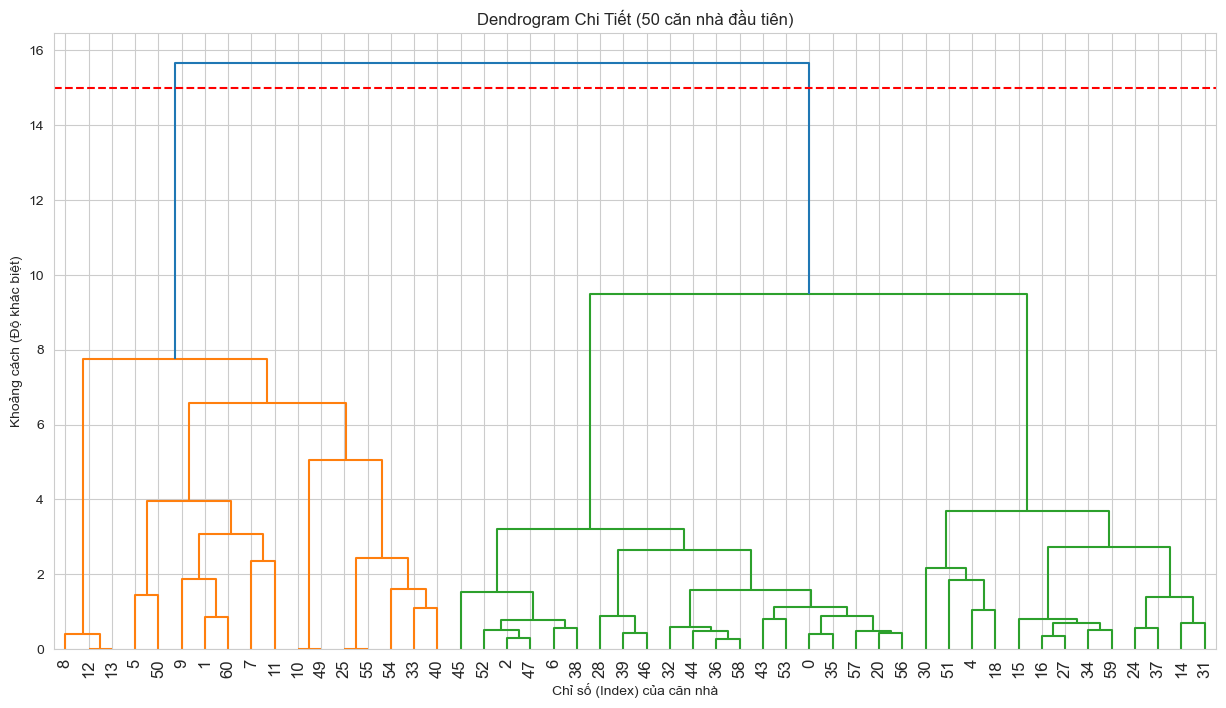

In [ ]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch


# 1. Chỉ lấy 50 mẫu đầu tiên để vẽ cho thoáng
limit = 50
data_sample = X_cluster_scaled[:limit]

# 2. Thiết lập kích thước biểu đồ lớn hơn
plt.figure(figsize=(15, 8))

# 3. Vẽ Dendrogram với tham số chỉnh chữ
dendrogram = sch.dendrogram(
    sch.linkage(data_sample, method='ward'),

    # Gán nhãn là số thứ tự (Index) của căn nhà trong file dữ liệu
    labels=df_clean.index[:limit],

    # Xoay chữ dọc 90 độ để không bị đè lên nhau
    leaf_rotation=90.,

    # Tăng kích thước chữ lên 12 cho dễ đọc
    leaf_font_size=12.,

    show_contracted=True
)

plt.title(f'Dendrogram Chi Tiết ({limit} căn nhà đầu tiên)')
plt.xlabel('Chỉ số (Index) của căn nhà')
plt.ylabel('Khoảng cách (Độ khác biệt)')

# Thêm đường cắt ngang màu đỏ để gợi ý số cụm (ví dụ cắt tại khoảng cách 15)
plt.axhline(y=15, color='r', linestyle='--')

plt.show()

### 4.5. Phân Tích Chi Tiết Đặc Điểm Từng Cụm (Profiling)

--- Bảng Đặc Điểm Các Phân Khúc (Clusters) ---
                          price  area  bedrooms  bathrooms  Count
Cluster_KMeans                                                   
0               5,528,062,623.3  58.5       2.8        2.4   4056
1              18,389,858,085.8 107.2      11.9       11.8    303
2              17,315,401,717.6 131.0       4.0        3.7   1048
3               9,310,391,925.2  71.0       4.8        4.8   2031


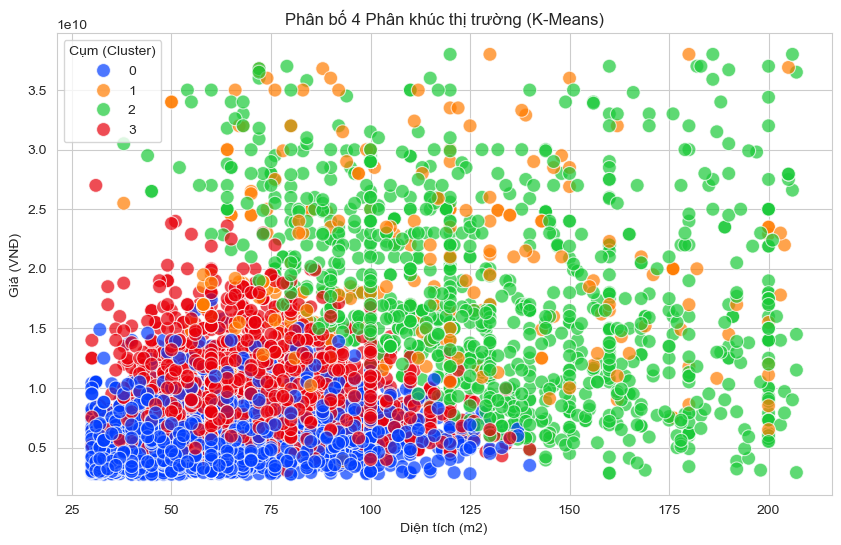

In [ ]:
# Gom nhóm và tính trung bình các đặc điểm
cluster_summary = df_clean.groupby('Cluster_KMeans')[['price', 'area', 'bedrooms', 'bathrooms']].mean()

# Thêm cột số lượng để biết độ lớn của cụm
cluster_summary['Count'] = df_clean['Cluster_KMeans'].value_counts()

# Định dạng hiển thị cho đẹp
pd.options.display.float_format = '{:,.1f}'.format
print("--- Bảng Đặc Điểm Các Phân Khúc (Clusters) ---")
print(cluster_summary)

# Trực quan hóa mối quan hệ giữa Giá và Diện tích theo Cụm
plt.figure(figsize=(10, 6))
# SỬA LỖI WARNING: Thêm hue='Cluster_KMeans'
sns.scatterplot(x='area', y='price', hue='Cluster_KMeans', data=df_clean, palette='bright', s=100, alpha=0.7)
plt.title(f'Phân bố 4 Phân khúc thị trường (K-Means)')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (VNĐ)')
plt.legend(title='Cụm (Cluster)')
plt.show()

### 4.6. Trực Quan Hóa Nâng Cao: Biểu đồ Hộp (Boxplot) Đa Biến

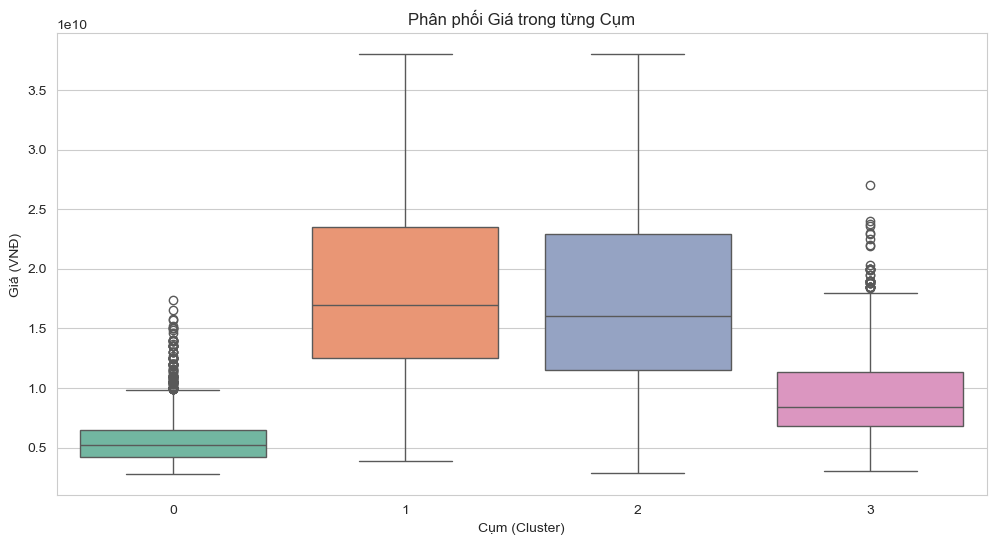

In [ ]:
plt.figure(figsize=(12, 6))
# SỬA LỖI WARNING: Thêm hue='Cluster_KMeans' và legend=False
sns.boxplot(x='Cluster_KMeans', y='price', data=df_clean, palette='Set2', hue='Cluster_KMeans', legend=False)
plt.title('Phân phối Giá trong từng Cụm')
plt.xlabel('Cụm (Cluster)')
plt.ylabel('Giá (VNĐ)')
plt.show()

## Phần 5: Tổng Kết Dự Án & Lưu Trữ Mô Hình

### 5.1. Tổng Hợp Kết Quả Dự Đoán Giá (Regression Recap)

In [ ]:
# 1. Sắp xếp bảng kết quả để tìm mô hình tốt nhất (R2 cao nhất)
# Lưu ý: comparison_df là bảng bạn đã tạo ở Phần 3.6
sorted_results = comparison_df.sort_values(by='R2', ascending=False)

print("--- BẢNG XẾP HẠNG CÁC MÔ HÌNH ---")
print(sorted_results)

# 2. Tự động lấy thông tin của mô hình đứng đầu bảng (Tốt nhất)
best_model_name = sorted_results.index[0]    # Lấy tên mô hình (ví dụ: Random Forest)
best_r2 = sorted_results.iloc[0]['R2']       # Lấy chỉ số R2
best_mae = sorted_results.iloc[0]['MAE']     # Lấy chỉ số MAE

print(f"\n✅ MÔ HÌNH CHIẾN THẮNG: {best_model_name}")
print(f"- Độ chính xác (R2): {best_r2:.2%}")
print(f"- Sai số trung bình (MAE): {best_mae:,.0f} VND")

# Giải thích ý nghĩa con số cho người đọc dễ hiểu
print(f"\n💡 Ý NGHĨA:")
print(f"Khi mô hình dự đoán giá một căn nhà, kết quả thường lệch khoảng +/- {best_mae:,.0f} VND so với giá thực tế.")
print(f"Ví dụ: Nếu máy định giá 5 tỷ, giá thị trường có thể nằm trong khoảng {5e9 - best_mae:,.0f} đến {5e9 + best_mae:,.0f} VND.")

--- BẢNG XẾP HẠNG CÁC MÔ HÌNH ---
                   R2             MAE            RMSE
Model                                                
Random Forest     0.6 2,244,792,220.4 3,679,810,001.9
Gradient Boosting 0.6 2,319,247,005.0 3,769,944,568.1
Decision Tree     0.4 2,637,666,464.3 4,430,779,452.4
Linear Regression 0.4 2,646,054,932.9 4,512,526,270.2

✅ MÔ HÌNH CHIẾN THẮNG: Random Forest
- Độ chính xác (R2): 59.16%
- Sai số trung bình (MAE): 2,244,792,220 VND

💡 Ý NGHĨA:
Khi mô hình dự đoán giá một căn nhà, kết quả thường lệch khoảng +/- 2,244,792,220 VND so với giá thực tế.
Ví dụ: Nếu máy định giá 5 tỷ, giá thị trường có thể nằm trong khoảng 2,755,207,780 đến 7,244,792,220 VND.


### 5.2. Định Danh Các Phân Khúc Thị Trường (Clustering Recap)

In [ ]:
# Tạo bảng tóm tắt đặc điểm để dễ kết luận
summary_table = df_clean.groupby('Cluster_KMeans')[['price', 'area', 'bedrooms', 'district']].agg({
    'price': 'mean',
    'area': 'mean',
    'bedrooms': 'median',
    'district': lambda x: x.mode()[0] # Lấy quận phổ biến nhất trong nhóm
}).reset_index()

# ...
def naming_cluster(cluster_id):
    if cluster_id == 0: return "Nhà Phố Bình Dân"
    elif cluster_id == 1: return "Nhà Trung Tâm/Căn Hộ"
    elif cluster_id == 2: return "Biệt Thự Cao Cấp"
    else: return "Nhà Ngoại Ô Diện Tích Lớn"

summary_table['Segment_Name'] = summary_table['Cluster_KMeans'].apply(naming_cluster)

print("--- HỒ SƠ PHÂN KHÚC THỊ TRƯỜNG ---")
print(summary_table[['Segment_Name', 'price', 'area', 'district', 'bedrooms']])

--- HỒ SƠ PHÂN KHÚC THỊ TRƯỜNG ---
                Segment_Name            price  area  district  bedrooms
0           Nhà Phố Bình Dân  5,528,062,623.3  58.5   Tân Phú       3.0
1       Nhà Trung Tâm/Căn Hộ 18,389,858,085.8 107.2   Quận 10      11.0
2           Biệt Thự Cao Cấp 17,315,401,717.6 131.0   Quận 12       4.0
3  Nhà Ngoại Ô Diện Tích Lớn  9,310,391,925.2  71.0  Bình Tân       4.0


### 5.3. Lưu Mô Hình (Deployment Preparation)

In [ ]:
import joblib

# 1. Lưu mô hình dự đoán giá tốt nhất
joblib.dump(best_model, 'real_estate_price_model.pkl')

# 2. Lưu bộ xử lý dữ liệu (Preprocessor) - CỰC KỲ QUAN TRỌNG
# Nếu không có cái này, bạn không thể xử lý dữ liệu mới giống như lúc train được
joblib.dump(preprocessor, 'preprocessor.pkl')

# 3. Lưu mô hình phân cụm (nếu cần dùng sau này)
joblib.dump(kmeans, 'customer_segmentation_model.pkl')

print("✅ Đã lưu thành công các mô hình vào file .pkl!")
print("Bạn có thể dùng lệnh 'model = joblib.load(filename)' để tái sử dụng.")

✅ Đã lưu thành công các mô hình vào file .pkl!
Bạn có thể dùng lệnh 'model = joblib.load(filename)' để tái sử dụng.


### 5.4. Kiến Nghị & Hướng Phát Triển (Future Work)

#### 1. Hạn chế của Mô hình hiện tại
* **Thiếu yếu tố vi mô về vị trí:** Mô hình hiện đang dừng lại ở mức Quận/Huyện (`district`). Trong bất động sản, giá trị phụ thuộc rất lớn vào vị trí cụ thể (tên đường, hẻm hay mặt tiền, bề rộng hẻm). Việc thiếu tọa độ (Kinh độ/Vĩ độ) hoặc phân loại đường khiến mô hình chưa phân biệt được nhà mặt tiền và nhà trong hẻm sâu tại cùng một phường.
* **Chưa khai thác dữ liệu văn bản:** Cột `description` chứa rất nhiều "từ khóa vàng" ảnh hưởng đến giá (ví dụ: *"nở hậu"*, *"hẻm xe hơi"*, *"thang máy"*, *"kết cấu BTCT"*, *"gần chợ"*) nhưng hiện tại chưa được đưa vào mô hình.
* **Yếu tố thời gian:** Giá bất động sản biến động mạnh theo chu kỳ kinh tế và lãi suất. Mô hình hiện tại là mô hình tĩnh, chưa tích hợp biến thời gian (Time Series) để dự báo xu hướng tăng/giảm trong tương lai.

#### 2. Đề xuất Ứng dụng Kinh doanh (Business Insights)
Từ kết quả dự đoán và phân cụm, chúng ta có thể triển khai các ứng dụng thực tế sau:

* **Công cụ "Săn Deal Hời" (Undervalued Property Finder):**
    * Sử dụng mô hình để định giá tham khảo cho tất cả các tin đăng mới.
    * Lọc ra các bất động sản có **Giá Rao Bán < Giá Dự Đoán** (với mức chênh lệch > 15-20%). Đây là tín hiệu cho thấy chủ nhà đang cần bán gấp hoặc định giá thấp hơn thị trường -> Cơ hội cho nhà đầu tư.
* **Hỗ trợ Định giá cho Người bán:**
    * Giúp chủ nhà đưa ra mức giá niêm yết hợp lý, tránh tình trạng "ngáo giá" (rao quá cao không ai mua) hoặc bán hớ (rao quá thấp).
* **Marketing theo Phân khúc (Cluster-based Marketing):**
    * *Nhóm "Nhà phố bình dân":* Tập trung quảng cáo các gói vay vốn ngân hàng, hỗ trợ tài chính lãi suất thấp.
    * *Nhóm "Biệt thự cao cấp":* Quảng cáo các dịch vụ thiết kế nội thất sang trọng, quản lý gia sản, an ninh 24/7.

#### 3. Lộ trình Phát triển Kỹ thuật (Technical Roadmap)
Để cải thiện chỉ số $R^2$ (hiện tại) và giảm sai số tuyệt đối ($MAE$), các bước nâng cấp kỹ thuật tiếp theo nên là:

* **Xử lý Ngôn ngữ Tự nhiên (NLP):**
    * Áp dụng kỹ thuật **TF-IDF** hoặc **Word Embedding** để trích xuất đặc trưng từ cột mô tả.
    * Tạo các biến nhị phân (Binary Features): `is_car_alley` (hẻm xe hơi), `is_corner` (lô góc), `has_elevator` (có thang máy).
* **Tích hợp API Địa lý:**
    * Sử dụng Google Maps API để tính khoảng cách chính xác từ căn nhà đến: Trung tâm Quận 1, trường học gần nhất, bệnh viện gần nhất.
* **Triển khai Web App (Deployment):**
    * Xây dựng giao diện web đơn giản bằng **Streamlit** hoặc **Flask**.
    * Người dùng nhập thông số (Diện tích, Số phòng, Vị trí) $\rightarrow$ Hệ thống trả về khoảng giá dự kiến ngay lập tức.

> **Kết luận:** Dự án đã xây dựng thành công quy trình phân tích và định giá bất động sản dựa trên dữ liệu. Với mô hình **Random Forest** làm nòng cốt, chúng ta đã nắm bắt được các yếu tố chính ảnh hưởng đến giá nhà. Việc bổ sung thêm dữ liệu phi cấu trúc (văn bản) và địa lý chi tiết trong tương lai hứa hẹn sẽ đưa độ chính xác của mô hình lên mức tiệm cận với chuyên gia định giá.

## Phần 6: Demo Dự Đoán (Deployment Demo)

In [ ]:
import joblib
import pandas as pd
import numpy as np

# --- BƯỚC 1: TẢI (LOAD) CÁC FILE ĐÃ LƯU ---
# Load mô hình dự đoán (Cái não đã học bài)
model = joblib.load('real_estate_price_model.pkl')

# Load bộ xử lý dữ liệu (Bộ công cụ để chuẩn hóa dữ liệu mới y hệt dữ liệu cũ)
preprocessor = joblib.load('preprocessor.pkl')

print("✅ Đã tải mô hình và bộ xử lý thành công!")

# --- BƯỚC 2: TẠO DỮ LIỆU CẦN DỰ ĐOÁN ---
# Lưu ý: Tên cột phải Y HỆT như lúc bạn huấn luyện (Train)
# Bạn nhập thông tin căn nhà cần định giá vào đây
new_house_data = pd.DataFrame({
    'area': [100],            # 100 mét vuông
    'bedrooms': [3],          # 3 phòng ngủ
    'bathrooms': [2],         # 2 phòng tắm
    'district': ['Quận 1'],   # Quận 7
    'legal_status': ['Sổ đỏ/ Sổ hồng'],

    # Các cột phụ nếu bạn có dùng trong Feature Engineering ở Phần 2
    # Nếu ở phần 2 bạn có tạo cột 'total_rooms', bạn phải tạo lại nó ở đây
    'total_rooms': [3 + 2],   # bedrooms + bathrooms
    'bath_per_bed': [2 / 3]   # bathrooms / bedrooms
})

print("\n--- Thông tin căn nhà mới ---")
print(new_house_data)

# --- BƯỚC 3: XỬ LÝ DỮ LIỆU (PREPROCESSING) ---
# Quan trọng: Dùng .transform() chứ KHÔNG dùng .fit_transform()
# Vì ta muốn dùng quy tắc cũ áp dụng cho người mới
new_house_processed = preprocessor.transform(new_house_data)

# --- BƯỚC 4: DỰ ĐOÁN (PREDICT) ---
# Dự đoán giá (kết quả trả về đang ở dạng Logarit do lúc train ta dùng log)
predicted_log_price = model.predict(new_house_processed)

# Chuyển đổi ngược từ Log -> Giá thực tế (VNĐ)
predicted_real_price = np.expm1(predicted_log_price)[0]

print(f"\n💰 GIÁ DỰ ĐOÁN CHO CĂN NHÀ NÀY LÀ: {predicted_real_price:,.0f} VNĐ")

✅ Đã tải mô hình và bộ xử lý thành công!

--- Thông tin căn nhà mới ---
   area  bedrooms  bathrooms district    legal_status  total_rooms  \
0   100         3          2   Quận 1  Sổ đỏ/ Sổ hồng            5   

   bath_per_bed  
0           0.7  

💰 GIÁ DỰ ĐOÁN CHO CĂN NHÀ NÀY LÀ: 13,112,125,112 VNĐ
